El set de datos
Usaremos el weather dataset, un set de datos del Instituto Planck para Biogeoquímica que contiene el registro histórico de diferentes variables climáticas.

En particular este dataset:

Contiene 31 diferentes features (temperatura del aire, presión atmosférica, humedad, etc.)
Cada variable ha sido recolectada con una periodicidad de 1 hora comenzando en el año 2025 del 01/01.

El problema a resolver
Como en todo proyecto de Ciencia de Datos y Machine Learning, el punto de partida es tener claro el problema que queremos resolver.

En esta serie de artículos lo que buscamos es desarrollar modelos predictivos basados en Redes LSTM usando los enfoques:

Univariado + single-step
Univariado + multi-step
Multivariado + single-step
Multivariado + multi-step
Implementaremos estos modelos predictivos en los próximos tutoriales de la serie, pero el punto de partida en cualquiera de estos casos es garantizar la integridad de nuestro dataset.

Lo anterior quiere decir que debemos asegurarnos de que nuestro dataset ha sido pre-procesado adecuadamente y que los datos resultarán adecuados para implementar las diferentes Redes LSTM.

Este es precisamente el objetivo de este tutorial, así que comencemos realizando la lectura del set de datos.

# Lectura del set de datos

Comencemos importando las librerías requeridas para nuestro proyecto así como realizando la lectura del set de datos (que se encuentra almacenado en formato CSV).

En particular importaremos las librerías «drive» de Google Colab así como las librerías Pandas y Matplotlib.

La lectura del dataset la realizaremos usando la función «read_csv» de Pandas:

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt

# Montar Google Drive
drive.mount('/gdrive', force_remount=True)

# Leer set de datos
ruta = '/gdrive/MyDrive/Series de tiempo/mpi_saale_2025.csv'
df = pd.read_csv(ruta)
df

Mounted at /gdrive


,Date Time,p (mbar),T (degC),rh (%),sh (g/kg),Tpot (K),Tdew (degC),VPmax (mbar),VPact (mbar),VPdef (mbar),...,ST008 (degC),ST016 (degC),ST032 (degC),ST064 (degC),ST128 (degC),SM008 (%),SM016 (%),SM032 (%),SM064 (%),SM128 (%)
0,01.01.2025 00:10:00,1007.12,-1.09,91.0,3.18,271.51,-2.36,5.64,5.13,0.51,...,1.62,2.52,3.89,6.35,9.28,36.87,33.37,33.37,31.51,31.04
1,01.01.2025 00:20:00,1006.72,-0.83,90.8,3.23,271.80,-2.14,5.75,5.22,0.53,...,1.62,2.52,3.89,6.35,9.28,36.86,33.37,33.37,31.51,31.05
2,01.01.2025 00:30:00,1006.60,0.25,85.3,3.28,272.88,-1.92,6.22,5.30,0.91,...,1.62,2.51,3.88,6.35,9.28,36.86,33.38,33.37,31.51,31.05
3,01.01.2025 00:40:00,1006.36,0.92,82.2,3.32,273.57,-1.76,6.53,5.37,1.16,...,1.61,2.51,3.88,6.35,9.28,36.85,33.38,33.37,31.51,31.04
4,01.01.2025 00:50:00,1006.14,1.12,82.1,3.37,273.79,-1.58,6.62,5.44,1.19,...,1.61,2.51,3.88,6.35,9.28,36.84,33.38,33.36,31.51,31.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51169,31.12.2025 23:20:00,997.97,3.67,83.3,4.14,276.98,1.12,7.95,6.62,1.33,...,0.99,1.68,2.81,5.20,8.46,37.64,31.93,32.26,22.58,30.67
51170,31.12.2025 23:30:00,997.85,3.63,83.5,4.13,276.95,1.10,7.92,6.62,1.31,...,0.99,1.69,2.81,5.20,8.46,37.65,31.93,32.26,22.58,30.67
51171,31.12.2025 23:40:00,997.73,3.57,83.5,4.12,276.90,1.05,7.89,6.59,1.30,...,0.99,1.69,2.81,5.20,8.46,37.65,31.93,32.26,22.58,30.67
51172,31.12.2025 23:50:00,997.62,3.63,82.9,4.11,276.97,1.00,7.93,6.57,1.36,...,0.99,1.69,2.81,5.20,8.46,37.65,31.93,32.26,22.58,30.67


Con lo anterior podemos verificar que el set de datos contiene 51174 registros y 31 variables, entre las que se encuentran la temperatura del aire, la presión y la velocidad y dirección del viento entre otras.

La primera fase de procesamiento consiste en convertir la columna «Date Time» del formato object (string y datos numéricos) al formato datetime.

Esto facilitará la visualización del set de datos y el análisis exploratorio, así como el pre-procesamiento.

In [ ]:
#Primero verifiquemos que el tipo de dato de esta columna es object:
df['Date Time'].dtype

dtype('O')

In [ ]:
#Para convertir esta columna del formato object al formato datetime podemos usar la función «to_datetime» de la librería Pandas:
df['datetime'] = pd.to_datetime(
    df['Date Time'],
    format = '%d.%m.%Y %H:%M:%S'
)

In [ ]:
#Una vez realizada la conversión, podemos fijar esta columna «datetime» como el nuevo índice de nuestro DataFrame de Pandas,
#usando la función «set_index»:
df = df.set_index('datetime')

#Organizar cronologicamente el dataset por fechas
df.sort_index(inplace=True)

#Eliminar columna original del DateTime
df = df.drop(columns=['Date Time'])
df

,p (mbar),T (degC),rh (%),sh (g/kg),Tpot (K),Tdew (degC),VPmax (mbar),VPact (mbar),VPdef (mbar),H2OC (mmol/mol),...,ST008 (degC),ST016 (degC),ST032 (degC),ST064 (degC),ST128 (degC),SM008 (%),SM016 (%),SM032 (%),SM064 (%),SM128 (%)
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:10:00,1007.12,-1.09,91.0,3.18,271.51,-2.36,5.64,5.13,0.51,5.10,...,1.62,2.52,3.89,6.35,9.28,36.87,33.37,33.37,31.51,31.04
2025-01-01 00:20:00,1006.72,-0.83,90.8,3.23,271.80,-2.14,5.75,5.22,0.53,5.18,...,1.62,2.52,3.89,6.35,9.28,36.86,33.37,33.37,31.51,31.05
2025-01-01 00:30:00,1006.60,0.25,85.3,3.28,272.88,-1.92,6.22,5.30,0.91,5.27,...,1.62,2.51,3.88,6.35,9.28,36.86,33.38,33.37,31.51,31.05
2025-01-01 00:40:00,1006.36,0.92,82.2,3.32,273.57,-1.76,6.53,5.37,1.16,5.33,...,1.61,2.51,3.88,6.35,9.28,36.85,33.38,33.37,31.51,31.04
2025-01-01 00:50:00,1006.14,1.12,82.1,3.37,273.79,-1.58,6.62,5.44,1.19,5.40,...,1.61,2.51,3.88,6.35,9.28,36.84,33.38,33.36,31.51,31.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 23:20:00,997.97,3.67,83.3,4.14,276.98,1.12,7.95,6.62,1.33,6.64,...,0.99,1.68,2.81,5.20,8.46,37.64,31.93,32.26,22.58,30.67
2025-12-31 23:30:00,997.85,3.63,83.5,4.13,276.95,1.10,7.92,6.62,1.31,6.63,...,0.99,1.69,2.81,5.20,8.46,37.65,31.93,32.26,22.58,30.67
2025-12-31 23:40:00,997.73,3.57,83.5,4.12,276.90,1.05,7.89,6.59,1.30,6.61,...,0.99,1.69,2.81,5.20,8.46,37.65,31.93,32.26,22.58,30.67


#Análisis exploratorio
1. Comprender variables del set de datos


In [ ]:
df.columns

Index(['p (mbar)', 'T (degC)', 'rh (%)', 'sh (g/kg)', 'Tpot (K)',
       'Tdew (degC)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'wd (deg)', 'rain (mm)',
       'SWDR (W/m**2)', 'SDUR (s)', 'TRAD (degC)', 'Rn (W/m**2)',
       'ST002 (degC)', 'ST004 (degC)', 'ST008 (degC)', 'ST016 (degC)',
       'ST032 (degC)', 'ST064 (degC)', 'ST128 (degC)', 'SM008 (%)',
       'SM016 (%)', 'SM032 (%)', 'SM064 (%)', 'SM128 (%)'],
      dtype='object')

Variable	Significado
- p (mbar): Presión atmosférica en milibares.
- T (degC)	Temperatura del aire en °C.
- rh (%)	Humedad relativa del aire (% de saturación).
- sh (g/kg)	Humedad específica: vapor de agua por kg de aire.
- Tpot (K)	Temperatura potencial del aire (en Kelvin).
- Tdew (degC)	Punto de rocío: temperatura donde el vapor se condensa.
- VPmax (mbar)	Presión máxima de vapor posible a esa temperatura.
- VPact (mbar)	Presión real de vapor de agua en el aire.
- VPdef (mbar)	Déficit de presión de vapor (aire seco vs saturado).
- H2OC (mmol/mol)	Concentración de vapor de agua en el aire.
- rho (g/m³)	Densidad del aire.
- wv (m/s)	Velocidad del viento.
- wd (deg)	Dirección del viento en grados.
- rain (mm)	Cantidad de lluvia en milímetros.
- SWDR (W/m²)	Radiación solar de onda corta recibida.
- SDUR (s)	Duración de radiación solar (segundos de sol).
- TRAD (degC)	Temperatura radiativa medida por radiación térmica.
- Rn (W/m²)	Radiación neta (balance energético).
- ST002 (degC)	Temperatura del suelo a 2 cm de profundidad.
- ST004 (degC)	Temperatura del suelo a 4 cm.
- ST008 (degC)	Temperatura del suelo a 8 cm.
- ST016 (degC)	Temperatura del suelo a 16 cm.
- ST032 (degC)	Temperatura del suelo a 32 cm.
- ST064 (degC)	Temperatura del suelo a 64 cm.
- ST128 (degC)	Temperatura del suelo a 128 cm.
- SM008 (%)	Humedad del suelo a 8 cm de profundidad.
- SM016 (%)	Humedad del suelo a 16 cm.
- SM032 (%)	Humedad del suelo a 32 cm.
- SM064 (%)	Humedad del suelo a 64 cm.
- SM128 (%)	Humedad del suelo a 128 cm.

Variable a predecir: T (degC)
Variables predictoras o covariables


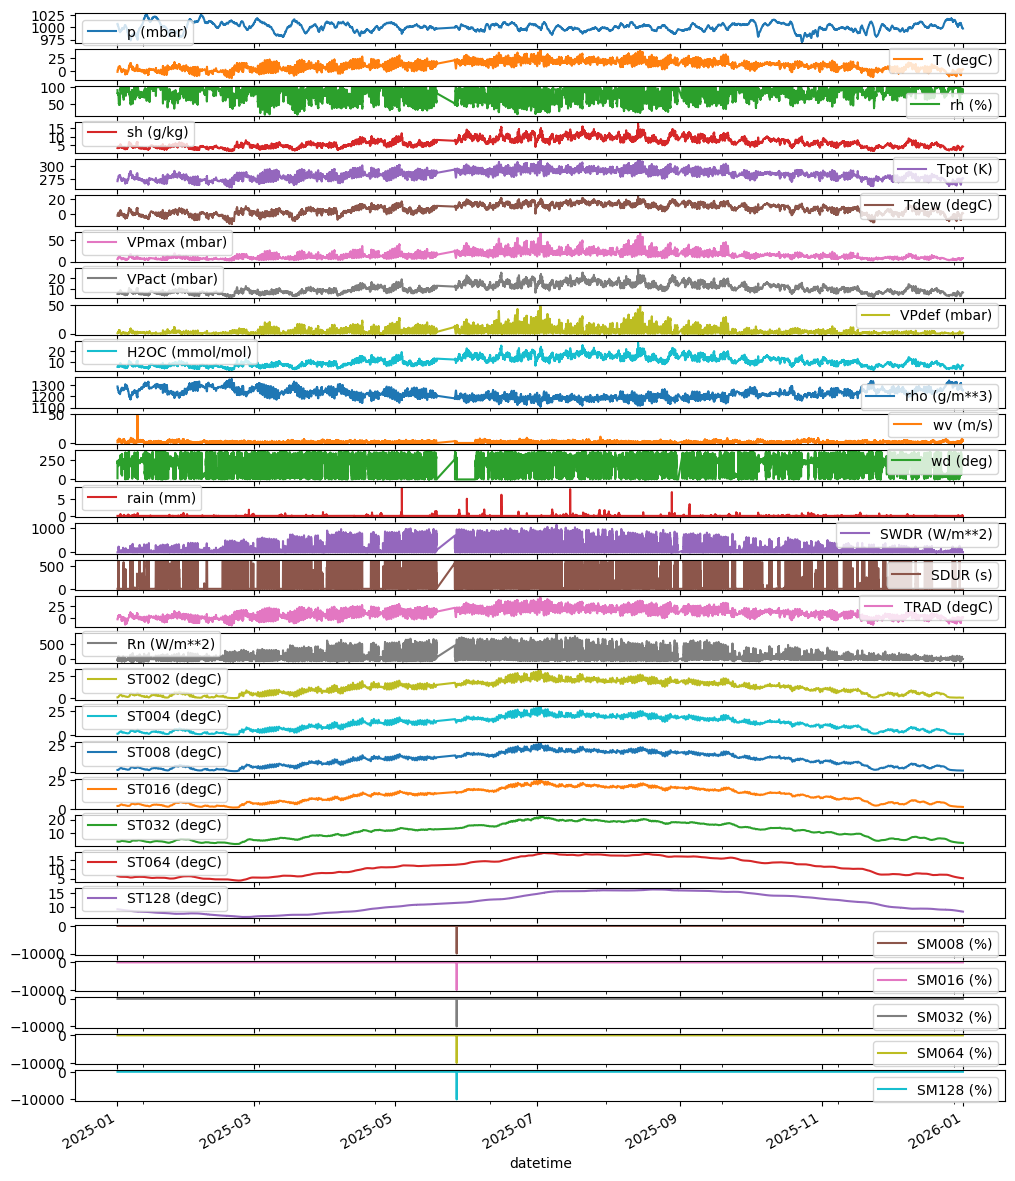

In [ ]:
# Dibujar la totalidad de registros
cols = df.columns

N = df.shape[0]       # Número de registros
plots = df[cols][0:N] # Series de tiempo individuales
plots.index = df.index[0:N] # Variable tiempo
_ = plots.plot(subplots=True, figsize=(12,16))


El segundo paso es verificar si hay datos faltantes

In [ ]:
print('Cantidad de NaNs')
for column in df:
  nans = df[column].isna().sum()
  print(f'\tColumna {column}: {nans}');

Cantidad de NaNs
	Columna p (mbar): 0
	Columna T (degC): 0
	Columna rh (%): 0
	Columna sh (g/kg): 0
	Columna Tpot (K): 0
	Columna Tdew (degC): 0
	Columna VPmax (mbar): 0
	Columna VPact (mbar): 0
	Columna VPdef (mbar): 0
	Columna H2OC (mmol/mol): 0
	Columna rho (g/m**3): 0
	Columna wv (m/s): 0
	Columna wd (deg): 0
	Columna rain (mm): 0
	Columna SWDR (W/m**2): 0
	Columna SDUR (s): 0
	Columna TRAD (degC): 0
	Columna Rn (W/m**2): 0
	Columna ST002 (degC): 0
	Columna ST004 (degC): 0
	Columna ST008 (degC): 0
	Columna ST016 (degC): 0
	Columna ST032 (degC): 0
	Columna ST064 (degC): 0
	Columna ST128 (degC): 0
	Columna SM008 (%): 0
	Columna SM016 (%): 0
	Columna SM032 (%): 0
	Columna SM064 (%): 0
	Columna SM128 (%): 0


Tercer paso, ver la periodicidad de las muestras

In [ ]:
#Verificar si la periodicidad de las muestras es exacamente
#1 hora (3600 secs)

#Calcular diferencias (en segundos) entre cada par de dato consecutivo
df_time_diffs = df.index.to_series().diff().dt.total_seconds()
print(df_time_diffs.value_counts())

datetime
600.0       51169
1200.0          2
687000.0        1
144600.0        1
Name: count, dtype: int64


Vemos que 51169 pares tienen 10 minutos de diferencia
2 pares tienen 20 minutos de diferencia
y otros dos pares separados que tienen datos totalmente desfasados

#Pre procesamiento
En caso de tener datos faltantes lo que se hace es una interpolación de datos.

In [ ]:
columns = ['VPmax (mbar)', 'H2OC (mmol/mol)', 'rho (g/m**3)']

for column in columns:
    df[column] = df[column].interpolate(method='linear')

print('Cantidad de NaNs:')
for column in df:
    nans = df[column].isna().sum()
    print(f'\tColumna {column}: {nans}')

Cantidad de NaNs:
	Columna p (mbar): 0
	Columna T (degC): 0
	Columna rh (%): 0
	Columna sh (g/kg): 0
	Columna Tpot (K): 0
	Columna Tdew (degC): 0
	Columna VPmax (mbar): 0
	Columna VPact (mbar): 0
	Columna VPdef (mbar): 0
	Columna H2OC (mmol/mol): 0
	Columna rho (g/m**3): 0
	Columna wv (m/s): 0
	Columna wd (deg): 0
	Columna rain (mm): 0
	Columna SWDR (W/m**2): 0
	Columna SDUR (s): 0
	Columna TRAD (degC): 0
	Columna Rn (W/m**2): 0
	Columna ST002 (degC): 0
	Columna ST004 (degC): 0
	Columna ST008 (degC): 0
	Columna ST016 (degC): 0
	Columna ST032 (degC): 0
	Columna ST064 (degC): 0
	Columna ST128 (degC): 0
	Columna SM008 (%): 0
	Columna SM016 (%): 0
	Columna SM032 (%): 0
	Columna SM064 (%): 0
	Columna SM128 (%): 0


#Ajustar periodicidad del data set

In [ ]:
#Eliminar datos duplicados para corregir el problema de diferencias, en este caso particular no hay, pero se haria de esta manera
df.drop_duplicates(keep='first', inplace=True, ignore_index=False)

#Verificamos que hayan sido eliminados
df_time_diffs = df.index.to_series().diff().dt.total_seconds()
print(df_time_diffs.value_counts())

datetime
600.0       51169
1200.0          2
687000.0        1
144600.0        1
Name: count, dtype: int64


Ahora correjimos los datos restantes para garantizar que entre pares de datos consecutivos habrá una periodicidad de 600 ms.
Se usa el metodo asfreq de datos de Pandas.Como aparecerán nuevos datos, usaremos el método bfill  para rellenar estos nuevos datos:

In [31]:
df2 = df.asfreq(freq='10min', method='bfill')

#Verificar que la totalidad del dataset tiene esta periodicidad
df_time_diffs = df2.index.to_series().diff().dt.total_seconds()
print(df_time_diffs.value_counts())

datetime
600.0    52559
Name: count, dtype: int64


Despues de hacer dicha interpolación debemos verificar que no existan datos NaNs

In [32]:
print('Cantidad de NaNs')
for column in df:
  nans = df[column].isna().sum()
  print(f'\tColumna {column}: {nans}');

Cantidad de NaNs
	Columna p (mbar): 0
	Columna T (degC): 0
	Columna rh (%): 0
	Columna sh (g/kg): 0
	Columna Tpot (K): 0
	Columna Tdew (degC): 0
	Columna VPmax (mbar): 0
	Columna VPact (mbar): 0
	Columna VPdef (mbar): 0
	Columna H2OC (mmol/mol): 0
	Columna rho (g/m**3): 0
	Columna wv (m/s): 0
	Columna wd (deg): 0
	Columna rain (mm): 0
	Columna SWDR (W/m**2): 0
	Columna SDUR (s): 0
	Columna TRAD (degC): 0
	Columna Rn (W/m**2): 0
	Columna ST002 (degC): 0
	Columna ST004 (degC): 0
	Columna ST008 (degC): 0
	Columna ST016 (degC): 0
	Columna ST032 (degC): 0
	Columna ST064 (degC): 0
	Columna ST128 (degC): 0
	Columna SM008 (%): 0
	Columna SM016 (%): 0
	Columna SM032 (%): 0
	Columna SM064 (%): 0
	Columna SM128 (%): 0


In [33]:
#Finalmente verificar las columnas modificadas y originales
#para constar que los valores promedio no cambien
for column in df:
  print(f'Promedios original/modificado: {df[column].mean():.2f}/{df2[column].mean():.2f}')

Promedios original/modificado: 1000.68/1000.62
Promedios original/modificado: 10.15/10.42
Promedios original/modificado: 80.71/80.00
Promedios original/modificado: 6.49/6.53
Promedios original/modificado: 283.25/283.53
Promedios original/modificado: 6.30/6.42
Promedios original/modificado: 14.32/14.58
Promedios original/modificado: 10.38/10.45
Promedios original/modificado: 3.95/4.13
Promedios original/modificado: 10.38/10.45
Promedios original/modificado: 1226.92/1225.67
Promedios original/modificado: 1.54/1.58
Promedios original/modificado: 175.99/178.38
Promedios original/modificado: 0.01/0.01
Promedios original/modificado: 126.84/138.90
Promedios original/modificado: 126.42/135.28
Promedios original/modificado: 9.59/9.91
Promedios original/modificado: 63.18/71.63
Promedios original/modificado: 11.27/11.43
Promedios original/modificado: 11.27/11.42
Promedios original/modificado: 11.19/11.32
Promedios original/modificado: 11.32/11.42
Promedios original/modificado: 11.31/11.38
Promedi

In [35]:
# Montar Google Drive
drive.mount('/gdrive', force_remount=True)
df2.to_csv(ruta+'wather_dataset_preprocesado.csv')

Mounted at /gdrive
